# Machine Learning Analysis of Customer Transactions

## Introduction

**Members**

*   Banquerigo, Serg Archer S.
*   Chavez, Jhonh Manuel C.
*   Garcia, Leslie Ann S.
*   Mainit, Jerson D.
*   Santos, Gene Stephene A.

**Section:** BSM CS 4B - G1

This project utilizes a retail transaction dataset sourced from Kaggle (by Ahmed Mohamed) to analyze customer purchasing behavior and predict total spending.

**Research Question:** Which customer behavior signals most influence total spending, and how well can they predict it?

The objective is to clean and preprocess the dataset, explore patterns through data visualization, and develop a machine learning model capable of predicting transaction spending based on customer and purchase attributes.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Load Dataset

In [4]:
df = pd.read_csv("retail_store_sales.csv") #Edit this part to where your dataset is located
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## Data Inspection

In [5]:
# Checking (rows, columns)
df.shape

(12575, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [7]:
df.describe(include="all")

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_2407494,CUST_05,Electric household essentials,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

**Findings:**
- Columns with missing values: `Item`, `Price Per Unit`, `Quantity`, `Total Spent`, `Discount Applied`
- No duplicate rows found in the dataset.

## Data Cleaning

This section focuses on cleaning and preprocessing the raw transaction data to ensure its quality and suitability for analysis and machine learning. Key steps include:

### Handling Missing Values
- **Column Normalization**: Column names were converted to lowercase and spaces replaced with underscores for consistency.
- **Data Type Conversion**: `transaction_date` was converted to datetime objects, and `quantity` to integer type.
- **`Item` Column**: Missing values were filled with 'Unknown' as no reliable imputation strategy could be determined.
- **`Price Per Unit` Column**: Missing values were imputed by calculating `Total Spent / Quantity` where possible.
- **`Quantity` Column**: Missing values were filled with the rounded mean of the existing quantities.
- **`Total Spent` Column**: Missing values were derived from `Price Per Unit × Quantity`.
- **`Discount Applied` Column**: Missing values were assumed to mean no discount, and thus filled with `False`.

### Handling Missing Values

In [10]:
# Create a copy of dataset
df_copy = df.copy()

# Normalize Columns
df_copy.columns = df_copy.columns.str.lower().str.replace(" ", "_")
df_copy.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')

In [11]:
# Converting data types
df_copy['transaction_date'] = pd.to_datetime(df_copy['transaction_date'])
df_copy['quantity'] = pd.to_numeric(df_copy['quantity'], errors='coerce').astype('Int64')

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  object        
 3   item              11362 non-null  object        
 4   price_per_unit    11966 non-null  float64       
 5   quantity          11971 non-null  Int64         
 6   total_spent       11971 non-null  float64       
 7   payment_method    12575 non-null  object        
 8   location          12575 non-null  object        
 9   transaction_date  12575 non-null  datetime64[ns]
 10  discount_applied  8376 non-null   object        
dtypes: Int64(1), datetime64[ns](1), float64(2), object(7)
memory usage: 1.1+ MB


In [12]:
# Verify Transaction ID Uniqueness
print(f"Total rows: {len(df_copy)}")
print(f"Unique Transaction IDs: {df_copy['transaction_id'].nunique()}")
print(f"Duplicate Transaction IDs: {df_copy.duplicated(subset=['transaction_id']).sum()}")

Total rows: 12575
Unique Transaction IDs: 12575
Duplicate Transaction IDs: 0


Since all `Transaction ID` values are unique, every row is a separate, independent transaction — there are no repeat or duplicate transaction records.

#### `Item` Column

Before deciding on an imputation strategy for `Item`, we test whether mode-per-category imputation is appropriate by checking the number of unique items per category, and how dominant the most frequent item is within each category.

In [13]:
# Check unique items per category
print(df_copy.groupby('category')['item'].nunique())

# Check mode dominance per category
df_copy.groupby('category')['item'].agg(
    lambda x: x.value_counts(normalize=True).iloc[0]
)

category
Beverages                             25
Butchers                              25
Computers and electric accessories    25
Electric household essentials         25
Food                                  25
Furniture                             25
Milk Products                         25
Patisserie                            25
Name: item, dtype: int64


category
Beverages                             0.088297
Butchers                              0.075299
Computers and electric accessories    0.075877
Electric household essentials         0.073069
Food                                  0.074334
Furniture                             0.077397
Milk Products                         0.076491
Patisserie                            0.073046
Name: item, dtype: float64

In [14]:
unique_item = df_copy.groupby('category')['item'].nunique()
print(unique_item)

category
Beverages                             25
Butchers                              25
Computers and electric accessories    25
Electric household essentials         25
Food                                  25
Furniture                             25
Milk Products                         25
Patisserie                            25
Name: item, dtype: int64


In [15]:
# Test if price_per_unit uniquely identifies each item
mapping_check = df_copy.groupby('price_per_unit')['item'].nunique()
print(mapping_check)
print(f"\nMax unique items per price: {mapping_check.max()}")
print(f"All prices map to exactly 1 item: {(mapping_check == 1).all()}")

price_per_unit
5.0     8
6.5     8
8.0     8
9.5     8
11.0    8
12.5    8
14.0    8
15.5    8
17.0    8
18.5    8
20.0    8
21.5    8
23.0    8
24.5    8
26.0    8
27.5    8
29.0    8
30.5    8
32.0    8
33.5    8
35.0    8
36.5    8
38.0    8
39.5    8
41.0    8
Name: item, dtype: int64

Max unique items per price: 8
All prices map to exactly 1 item: False


#### `Item` Column

The results show that each price point maps to up to **8 different items**
(`All prices map to exactly 1 item: False`), meaning `price_per_unit` cannot
be used to reliably infer the missing item name. Similarly, no single item
dominates within any category (mode frequency ~7–9%), making mode-per-category
imputation unreliable as well.

Since no deterministic mapping exists, missing `Item` values are filled with
`"Unknown"` to preserve the rows without introducing false assumptions.

In [16]:
df_copy['item'] = df_copy['item'].fillna("Unknown")

# Verify
df_copy.isnull().sum()

transaction_id         0
customer_id            0
category               0
item                   0
price_per_unit       609
quantity             604
total_spent          604
payment_method         0
location               0
transaction_date       0
discount_applied    4199
dtype: int64

#### `Price Per Unit` Column

Derived from `Total Spent / Quantity` where possible.

In [17]:
df_copy['price_per_unit'] = df_copy['price_per_unit'].fillna(df_copy['total_spent'] / df_copy['quantity'])
df_copy.isnull().sum()

transaction_id         0
customer_id            0
category               0
item                   0
price_per_unit         0
quantity             604
total_spent          604
payment_method         0
location               0
transaction_date       0
discount_applied    4199
dtype: int64

#### `Quantity` Column

Filled with the column mean (rounded to the nearest whole unit).

In [18]:
df_copy['quantity'] = df_copy['quantity'].fillna(df_copy['quantity'].mean().round())

df_copy.isnull().sum()

transaction_id         0
customer_id            0
category               0
item                   0
price_per_unit         0
quantity               0
total_spent          604
payment_method         0
location               0
transaction_date       0
discount_applied    4199
dtype: int64

#### `Total Spent` Column

Derived from `Price Per Unit × Quantity`.

In [19]:
df_copy['total_spent'] = df_copy['total_spent'].fillna(df_copy['price_per_unit'] * df_copy['quantity'])

df_copy.isnull().sum()

transaction_id         0
customer_id            0
category               0
item                   0
price_per_unit         0
quantity               0
total_spent            0
payment_method         0
location               0
transaction_date       0
discount_applied    4199
dtype: int64

#### `Discount Applied` Column

We assume that a missing record means no discount was applied.

In [20]:
df_copy['discount_applied'] = df_copy['discount_applied'].fillna(False)

df_copy.isnull().sum()

C:\Users\PC\AppData\Local\Temp\ipykernel_19240\468549674.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['discount_applied'] = df_copy['discount_applied'].fillna(False)


transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64

## Feature Engineering and Encoding

To prepare the dataset for machine learning, we need to convert categorical features into a numerical format that models can understand. This process is called **One-Hot Encoding**.

`pd.get_dummies(df_copy, drop_first=True)` performs this operation:
- It converts categorical columns (like `category`, `item`, `payment_method`, `location`) into new binary columns.
- For each unique value in a categorical column, a new column is created. If `drop_first=True` is set, one of the binary columns for each category is dropped to avoid multicollinearity, which can be beneficial for some models.

### Extracting Features from `transaction_date`

To make use of the `transaction_date` for our model, we'll extract several numerical features from it:
- **Year**: The year of the transaction.
- **Month**: The month of the transaction.
- **Day**: The day of the month of the transaction.
- **Day of Week**: The day of the week (Monday=0, Sunday=6).
- **Day of Year**: The day number within the year.
- **Week of Year**: The week number within the year.

After extracting these features, the original `transaction_date` column will be dropped as it is no longer needed in its raw format and is not suitable for direct model input.

In [21]:
# Extract temporal features from 'transaction_date'
df_copy['transaction_year'] = df_copy['transaction_date'].dt.year
df_copy['transaction_month'] = df_copy['transaction_date'].dt.month
df_copy['transaction_day'] = df_copy['transaction_date'].dt.day
df_copy['transaction_dayofweek'] = df_copy['transaction_date'].dt.dayofweek
df_copy['transaction_dayofyear'] = df_copy['transaction_date'].dt.dayofyear
df_copy['transaction_weekofyear'] = df_copy['transaction_date'].dt.isocalendar().week.astype(int)

# Drop the original 'transaction_date' column
df_copy = df_copy.drop('transaction_date', axis=1)

df_copy.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,discount_applied,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_dayofyear,transaction_weekofyear
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,True,2024,4,8,0,99,15
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,True,2023,7,23,6,204,29
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,False,2022,10,5,2,278,40
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,False,2022,5,7,5,127,18
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,False,2022,10,2,6,275,39


In [22]:
df_encoded = pd.get_dummies(df_copy, dtype='int', drop_first=True)
df_encoded.head()

,price_per_unit,quantity,total_spent,discount_applied,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_dayofyear,transaction_weekofyear,...,item_Item_9_CEA,item_Item_9_EHE,item_Item_9_FOOD,item_Item_9_FUR,item_Item_9_MILK,item_Item_9_PAT,item_Unknown,payment_method_Credit Card,payment_method_Digital Wallet,location_Online
0,18.5,10,185.0,True,2024,4,8,0,99,15,...,0,0,0,0,0,0,0,0,1,1
1,29.0,9,261.0,True,2023,7,23,6,204,29,...,0,0,0,0,0,0,0,0,1,1
2,21.5,2,43.0,False,2022,10,5,2,278,40,...,0,0,0,0,0,0,0,1,0,1
3,27.5,9,247.5,False,2022,5,7,5,127,18,...,0,0,0,0,0,0,0,1,0,1
4,12.5,7,87.5,False,2022,10,2,6,275,39,...,0,0,0,0,0,0,0,0,1,1


## Exploratory Data Analysis (EDA)

This section involves analyzing the dataset to summarize its main characteristics, often with visual methods. EDA helps in understanding the data's distribution, identifying patterns, detecting outliers, and forming hypotheses, which are crucial steps before building a machine learning model. We will explore distributions of key variables, relationships between them, and the impact of discounts and payment methods on total spending.

### Quantity vs Total Spending

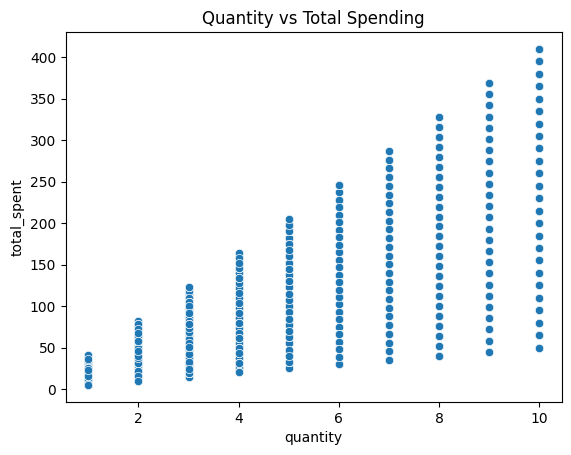

In [23]:
plt.figure()
sns.scatterplot(x='quantity', y='total_spent', data=df_encoded)
plt.title("Quantity vs Total Spending")
plt.show()

### Payment Method vs Spending

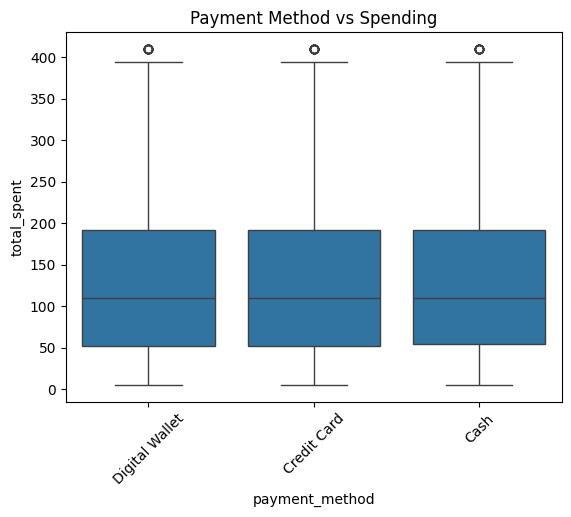

In [24]:
plt.figure()
sns.boxplot(x='payment_method', y='total_spent', data=df_copy)
plt.xticks(rotation=45)
plt.title("Payment Method vs Spending")
plt.show()

### Discount Impact on Spending

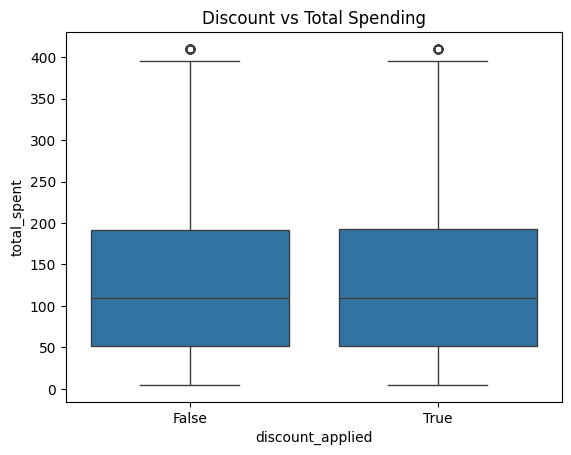

In [25]:
plt.figure()
sns.boxplot(x='discount_applied', y='total_spent', data=df_encoded)
plt.title("Discount vs Total Spending")
plt.show()

### Distribution of Total Spending

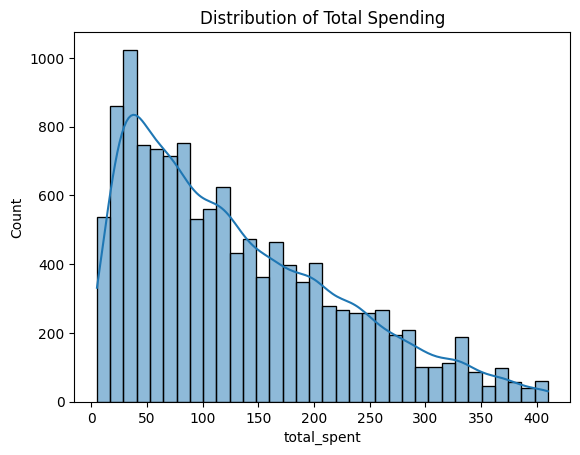

In [26]:
plt.figure()
sns.histplot(df_copy['total_spent'], kde=True)
plt.title("Distribution of Total Spending")
plt.show()

## Feature Selection

In this step, we select the features (input variables) that will be used to train our machine learning model. The goal is to choose variables that are most relevant for predicting the target variable, `total_spent`.

- `df_model = df_encoded.drop(columns=['transaction_id', 'customer_id'], errors='ignore')`: This line creates a new DataFrame `df_model` by dropping `transaction_id` and `customer_id` from `df_encoded`. These columns are typically unique identifiers and do not contribute meaningfully to predictive power.
- `X = df_model.drop(['total_spent', 'price_per_unit'] , axis=1)`: Here, `X` represents our feature matrix. We drop the target variable `total_spent` and `price_per_unit` (which is highly correlated with `total_spent` and `quantity`) from `df_model` to avoid data leakage and direct circular dependency.
- `y = df_model['total_spent']`: This line defines `y` as our target variable, which is the `total_spent` column that the model will try to predict.

In [27]:
df_model = df_encoded.drop(columns=['transaction_id', 'customer_id'], errors='ignore')

X = df_model.drop(['total_spent', 'price_per_unit'] , axis=1)
y = df_model['total_spent']


## Train-Test Split

To evaluate the performance of our machine learning model, we split the dataset into two subsets: a training set and a testing set.

- **Training Set (`X_train`, `y_train`)**: This subset is used to train the model, allowing it to learn the patterns and relationships within the data.
- **Testing Set (`X_test`, `y_test`)**: This subset is used to evaluate the model's performance on unseen data. By testing on data the model has not encountered during training, we can get an unbiased estimate of its generalization capability.

`test_size=0.2` indicates that 20% of the data will be used for testing, and the remaining 80% for training. `random_state=42` ensures reproducibility, meaning the split will be the same every time the code is run.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training (Random Forest)

We are using the `RandomForestRegressor` from `sklearn.ensemble` to build our predictive model. A Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the mean prediction (regression) of the individual trees.

Key parameters used:
- `n_estimators=200`: The number of trees in the forest. A higher number generally improves performance but also increases computation time.
- `max_depth=None`: Nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples. This allows the trees to grow fully.
- `min_samples_split=5`: The minimum number of samples required to split an internal node. This helps control overfitting.
- `min_samples_leaf=2`: The minimum number of samples required to be at a leaf node. This also helps control overfitting.
- `random_state=42`: Controls the randomness of the bootstrapping of the samples used when building trees and the sampling of the features to consider when looking for the best split at each node. Ensures reproducibility.
- `n_jobs=-1`: Uses all available processors for parallel computation, speeding up training.

In [29]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

## Predictions

After training the Random Forest Regressor, the next step is to use the trained model to make predictions on the unseen test set (`X_test`). This is done using the `predict()` method of the `rf` (Random Forest) object, which generates an array of predicted `total_spent` values for each transaction in the test set.

In [30]:
y_pred = rf.predict(X_test)

## Model Evaluation

After making predictions, it's crucial to evaluate the model's performance to understand how well it generalized to unseen data. We use several common regression metrics for this purpose:

-   **Mean Absolute Error (MAE)**: This is the average of the absolute differences between predictions and actual observations. It measures the average magnitude of the errors in a set of predictions, without considering their direction. A lower MAE indicates a better model.

-   **Mean Squared Error (MSE)**: This is the average of the squared differences between predictions and actual observations. It gives more weight to larger errors, making it sensitive to outliers. A lower MSE indicates a better model.

-   **R-squared (R²)**: Also known as the coefficient of determination, R² measures the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² of 1 indicates that the model perfectly predicts the target variable, while an R² of 0 indicates that the model explains none of the variability of the response data around its mean. A higher R² indicates a better fit of the model to the data.

In [31]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)


MAE: 26.684870291730572
MSE: 1498.2896308154036
R²: 0.832745811387126


### Model Performance Summary

The Random Forest Regressor demonstrated strong performance in predicting `total_spent`, achieving the following metrics:

*   **Mean Absolute Error (MAE):** 26.68
    *   On average, our model's predictions for total spending were off by approximately $26.68.
*   **Mean Squared Error (MSE):** 1498.29
    *   This metric penalizes larger errors more heavily. A value of 1498.29 indicates the average squared difference between predicted and actual values.
*   **R-squared (R²):** 0.8327
    *   An R² value of approximately 0.83 means that the model explains about 83.27% of the variance in the `total_spent` variable. This indicates that the model provides a good fit for the data and can explain a significant portion of the variability in customer spending.

## Feature Importance

Feature importance quantifies the contribution of each input variable to the model's predictive power. In a Random Forest model, importance is typically measured by the decrease in impurity (e.g., Gini impurity for classification or MSE for regression) brought about by splits on a given feature, averaged across all trees in the forest. A higher importance score indicates that a feature is more critical in determining the `total_spent`.




In [32]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)


quantity                 0.509752
transaction_day          0.018505
transaction_dayofyear    0.017595
item_Item_2_BEV          0.012915
item_Item_25_FUR         0.011623
item_Item_1_MILK         0.011069
item_Item_25_EHE         0.011002
transaction_dayofweek    0.010948
item_Item_25_BUT         0.010163
item_Item_25_FOOD        0.009748
dtype: float64

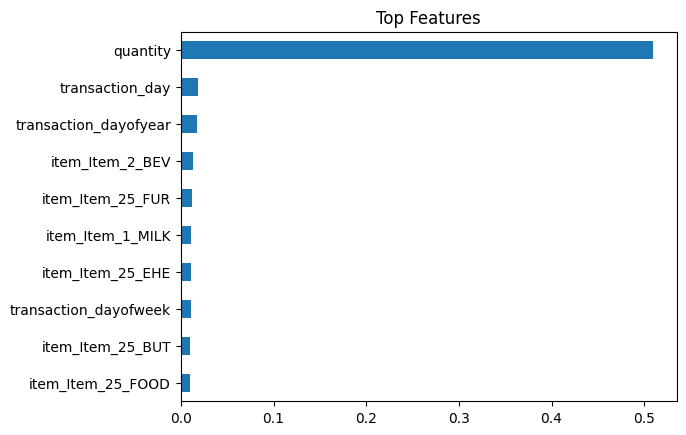

In [33]:
plt.figure()
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()


## Actual vs Predicted

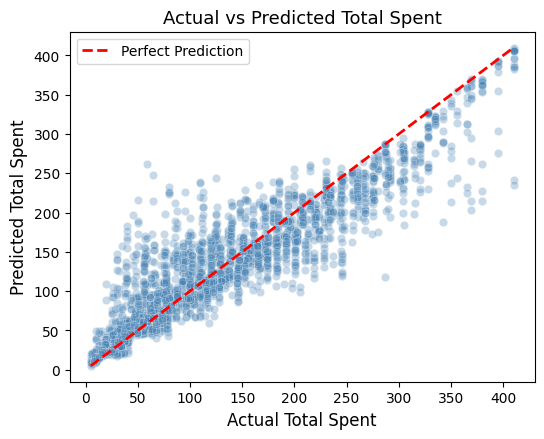

In [34]:
fig = plt.figure(figsize=(6, 10))

ax1 = fig.add_subplot(2, 2, (1, 2))
ax1.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Total Spent', fontsize=12)
ax1.set_ylabel('Predicted Total Spent', fontsize=12)
ax1.set_title('Actual vs Predicted Total Spent', fontsize=13)
ax1.legend()


The scatter plot above displays the relationship between the actual `total_spent` values and the values predicted by our Random Forest Regressor.

- Each point represents a single transaction, with its horizontal position indicating the actual spending and its vertical position showing the model's prediction.
- The red dashed line represents the 'Perfect Prediction' scenario, where `Actual Total Spent = Predicted Total Spent`.
- A model with high accuracy would have most of its data points clustered tightly along this red line. Deviations from the line indicate prediction errors.

From the plot, we can observe that most points are relatively close to the perfect prediction line, indicating that the model generally makes good predictions. However, there's some scatter, especially at higher spending values, suggesting areas where the model could potentially be improved.

## Conclusion

This project successfully addressed our core research question:

1.  **Which signals most influence spending?** Feature importance analysis revealed that **`quantity`** is the most influential behavior signal, followed by temporal features (transaction day) and specific item categories.
2.  **How well can we predict it?** The Random Forest Regressor achieved an **R² score of 0.8327**, indicating that these signals can explain approximately **83.27%** of the variance in customer spending.

Through thorough data cleaning—including handling missing values in 'Item', 'Price Per Unit', 'Quantity', and 'Total Spent'—and extracting temporal features, the model provides a reliable tool for business strategies such as personalized marketing and inventory management. While the model is strong, the 'Actual vs Predicted' scatter plot suggests potential for further refinement at higher spending amounts.